In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic_transport_data.csv")

print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(297840, 14)


,date,route_id,stop_id,stop_name,hour,day_of_week,is_weekend,is_holiday,peak_hour,passenger_count,bus_capacity,buses_allocated,distance_km,travel_time_min
0,2025-08-01,R101,S01,Central Station,6,4,0,0,0,41,40,3,2.32,9
1,2025-08-01,R101,S01,Central Station,7,4,0,0,1,163,40,5,7.25,23
2,2025-08-01,R101,S01,Central Station,8,4,0,0,1,159,40,5,14.11,50
3,2025-08-01,R101,S01,Central Station,9,4,0,0,1,166,40,4,5.10,18
4,2025-08-01,R101,S01,Central Station,10,4,0,0,0,45,40,2,7.76,23


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297840 entries, 0 to 297839
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             297840 non-null  str    
 1   route_id         297840 non-null  str    
 2   stop_id          297840 non-null  str    
 3   stop_name        297840 non-null  str    
 4   hour             297840 non-null  int64  
 5   day_of_week      297840 non-null  int64  
 6   is_weekend       297840 non-null  int64  
 7   is_holiday       297840 non-null  int64  
 8   peak_hour        297840 non-null  int64  
 9   passenger_count  297840 non-null  int64  
 10  bus_capacity     297840 non-null  int64  
 11  buses_allocated  297840 non-null  int64  
 12  distance_km      297840 non-null  float64
 13  travel_time_min  297840 non-null  int64  
dtypes: float64(1), int64(9), str(4)
memory usage: 31.8 MB


In [3]:
df.describe()

,hour,day_of_week,is_weekend,is_holiday,peak_hour,passenger_count,bus_capacity,buses_allocated,distance_km,travel_time_min
count,297840.000000,297840.000000,297840.000000,297840.000000,297840.000000,297840.000000,297840.0,297840.000000,297840.000000,297840.000000
mean,14.000000,3.002740,0.284932,0.032877,0.411765,60.606611,40.0,2.116361,8.511430,27.155741
std,4.898988,1.997946,0.451383,0.178314,0.492154,43.523036,0.0,1.147279,3.754171,12.848527
min,6.000000,0.000000,0.000000,0.000000,0.000000,5.000000,40.0,1.000000,2.000000,5.000000
25%,10.000000,1.000000,0.000000,0.000000,0.000000,25.000000,40.0,1.000000,5.260000,16.000000
50%,14.000000,3.000000,0.000000,0.000000,0.000000,53.000000,40.0,2.000000,8.520000,27.000000
75%,18.000000,5.000000,1.000000,0.000000,1.000000,88.000000,40.0,3.000000,11.760000,37.000000
max,22.000000,6.000000,1.000000,1.000000,1.000000,225.000000,40.0,7.000000,15.000000,59.000000


In [4]:
df.isnull().sum()

date               0
route_id           0
stop_id            0
stop_name          0
hour               0
day_of_week        0
is_weekend         0
is_holiday         0
peak_hour          0
passenger_count    0
bus_capacity       0
buses_allocated    0
distance_km        0
travel_time_min    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

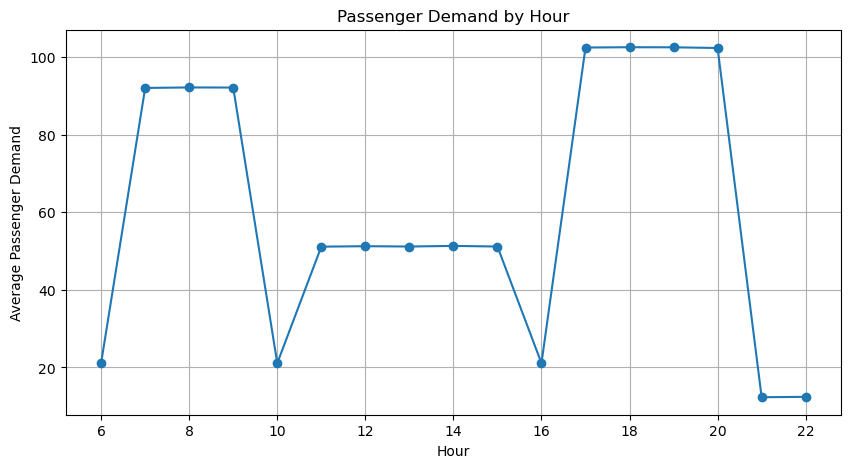

In [6]:
hourly = df.groupby("hour")["passenger_count"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly.values, marker="o")
plt.xlabel("Hour")
plt.ylabel("Average Passenger Demand")
plt.title("Passenger Demand by Hour")
plt.grid()
plt.show()

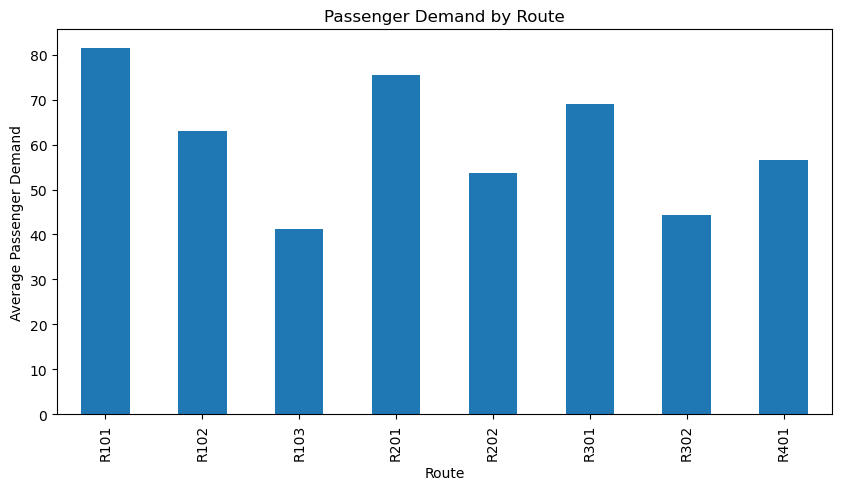

In [7]:
route_demand = df.groupby("route_id")["passenger_count"].mean()

plt.figure(figsize=(10,5))
route_demand.plot(kind="bar")
plt.xlabel("Route")
plt.ylabel("Average Passenger Demand")
plt.title("Passenger Demand by Route")
plt.show()

In [8]:
weekend_demand = df.groupby("is_weekend")["passenger_count"].mean()

print(weekend_demand)

is_weekend
0    67.175973
1    44.120039
Name: passenger_count, dtype: float64


In [9]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [10]:
features = [
    "route_id",
    "stop_id",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "peak_hour",
    "distance_km",
    "travel_time_min"
]

target = "passenger_count"

In [11]:
df["distance_km"] = df["distance_km"].fillna(
    df["distance_km"].median()
)

df["travel_time_min"] = df["travel_time_min"].fillna(
    df["travel_time_min"].median()
)

In [12]:
df = df.drop_duplicates()

In [13]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [14]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [17]:
categorical_features = [
    "route_id",
    "stop_id"
]

In [18]:
numerical_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "peak_hour",
    "distance_km",
    "travel_time_min"
]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [20]:
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

In [21]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [22]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['route_id','stop_id','hour',...,'peak_hour','distance_km', 'travel_time_min']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [25]:
predictions = pipeline.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 8.281360528743459
RMSE: 10.399614026472442
R²: 0.9426370053464177


In [27]:
sample = X_test.iloc[[0]]

actual = y_test.iloc[0]

prediction = pipeline.predict(sample)[0]

print("Actual demand:", actual)
print("Predicted demand:", round(prediction))

Actual demand: 21
Predicted demand: 33


In [28]:
BUS_CAPACITY = 40

predicted_demand = round(prediction)

required_buses = int(
    np.ceil(predicted_demand / BUS_CAPACITY)
)

print("Predicted demand:", predicted_demand)
print("Required buses:", required_buses)

Predicted demand: 33
Required buses: 1


In [29]:
original_row = test.iloc[[0]]

current_buses = int(
    original_row["buses_allocated"].iloc[0]
)

difference = required_buses - current_buses

In [30]:
if difference > 0:
    recommendation = f"Deploy {difference} additional bus(es)"

elif difference < 0:
    recommendation = f"Potentially reallocate {abs(difference)} bus(es)"

else:
    recommendation = "Current allocation is sufficient"

print(recommendation)

Current allocation is sufficient


In [32]:
import joblib

joblib.dump(
    pipeline,
    "../models/transitq_model.pkl"
)

['../models/transitq_model.pkl']